# Attenuator Calibration Lab Script

Dirty science-lab notebook for attenuator calibration. It has two paths:

- embedded auto-calibration: run firmware, retrieve retained HAC4 metadata and raw record chunks, and inspect them with helper plots;
- manual exploration: call `pcb.atten()`, wait, and read `pcb.pd()` so thresholds and failure modes can be changed quickly without reflashing.

Measure dark in a preceding cell or in the dark cell below before collecting either dataset.
The embedded firmware is the source of truth; the manual path below is intentionally written to mirror the current C state machine.



In [22]:
from __future__ import annotations

from dataclasses import dataclass
import math
import time
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np

try:
    from scipy.optimize import least_squares
except ImportError:
    least_squares = None

import hispec_fibpcb as hspcb

BROKER = "hispec.caltech.edu"
LASER = "1028y"
OUTPUT = "yj_ao"
FIBER = "M"
PD_CHANNEL = "yj"

TAKE_DARK = False
DARK_DURATION_MS = 2000

MANUAL_FIT_METHOD: Literal["firmware", "scipy"] = "firmware"
MANUAL_FIT_MODEL: Literal["erf", "field"] = "erf"
MANUAL_FIT_CORRECTION = True
MANUAL_DWELL_S = 0.55
MANUAL_DWELL_MS = int(round(MANUAL_DWELL_S * 1000))
MANUAL_SWEEP_STEP_MV = 50.0
MANUAL_COMPANION_SEARCH_MIN_STEP_MV = 5.0
MANUAL_COMPANION_SEARCH_MAX_TRIES = 16
MANUAL_MAX_RECORDS = 128
MANUAL_INITIAL_LASER_LEVELS_PCT = (100.0, 50.0, 5.0)
MANUAL_SNR_USABLE = hspcb.ATTENUATOR_CAL_SNR_USABLE
MANUAL_ADC_LSB_MV = 0.1875
MANUAL_DAC_SIGMA_MV = 3.0
MANUAL_FIT_MAX_ITER = 30
MANUAL_FIT_INITIAL_LAMBDA = 1.0e-3
MANUAL_FIT_MIN_SLOPE = 1.0e-12
MANUAL_FIT_MAX_SLOPE = 1.0
FIRMWARE_CORRECTION_TERMS = hspcb.ATTENUATOR_MODEL_CORRECTION_TERMS
MANUAL_CORRECTION_MIN_TERMS = FIRMWARE_CORRECTION_TERMS
MANUAL_CORRECTION_MAX_TERMS = 8
MANUAL_CORRECTION_RIDGE = 1.0e-6
MANUAL_CORRECTION_MIN_RMS_IMPROVEMENT_DB = 0.02
MANUAL_CORRECTION_START_DB = hspcb.ATTENUATOR_MODEL_CORRECTION_START_DB
MANUAL_TAIL_FLOOR_POINTS = 3
MANUAL_RECORDS_PER_CHUNK = 37
TX_MIN = hspcb.ATTEN_CAL_MIN_TX
TX_MAX = hspcb.ATTEN_CAL_MAX_TX
MAX_DAC_MV = hspcb.ATTENUATOR_DRIVE_MAX_MV
ADC_CLIP_MV = hspcb.ATTENUATOR_ADC_CLIP_MV
GAIN = hspcb.ATTENUATOR_DEFAULT_GAIN
FIT_MIN_SIGMA_DB = hspcb.ATTENUATOR_FIT_MIN_SIGMA_DB

pcb = hspcb.HispecFibPcb(BROKER, connect=True)
pcb.status(), pcb.time()


(Status(
   fw='45ba998aa6d8',
   boots=2,
   board='tib',
   board_ok=True,
   mems_switches=8,
   relay_err=0,
   amb_c=21.25,
   pd_on_s=0,
   laserbank_on_s=89855,
   lastcmd=LastCommand(name='atten/1028y', src='mqtt', t_ms=84935241),
   ip=None,
   lasers=(),
   attens=()
 ),
 TimeStatus(utc=1782267744694, uptime_s=89856))

## Dark

Dark is deliberately outside attenuator calibration. Take or force the channel dark here, then leave calibration to read the photodiode configurable window.



In [53]:
pcb.pd(PD_CHANNEL)



PhotodiodeValues(
  yj=PhotodiodeChannelValues(
  raw=-28,
  mv=-5.25,
  net_mv=-5.25,
  net_err_mv=0.188,
  power_uw=0,
  power_err_uw=0,
  dark_mv=0,
  dark_err_mv=0,
  window=PhotodiodeWindow(
  duration_ms=500,
  failed_samples=0,
  mean_mv=-1.575,
  mean_net_mv=-1.575,
  rms_mv=1.485,
  mean_net_err_mv=0.297,
  min_mv=-5.25,
  max_mv=2.062,
  power_uw=0,
  power_err_uw=0
),
  pd_is_off=False,
  ontime_s=0
),
  hk=None
)

In [3]:
if TAKE_DARK:
    pcb.pd_dark(PD_CHANNEL, duration_ms=DARK_DURATION_MS, persist=False)
pcb.pd(PD_CHANNEL)



PhotodiodeValues(
  yj=PhotodiodeChannelValues(
  raw=-8,
  mv=-1.5,
  net_mv=-0.066,
  net_err_mv=1.21,
  power_uw=0,
  power_err_uw=0,
  dark_mv=-1.434,
  dark_err_mv=1.195,
  window=PhotodiodeWindow(
  duration_ms=500,
  failed_samples=0,
  mean_mv=-1.673,
  mean_net_mv=-0.238,
  rms_mv=1.427,
  mean_net_err_mv=1.229,
  min_mv=-4.875,
  max_mv=1.5,
  power_uw=0,
  power_err_uw=0
),
  pd_is_off=False,
  ontime_s=3
),
  hk=None
)

## Embedded Firmware Path

Run the on-board algorithm, then fetch metadata plus fixed raw-record chunks. The Python helper derives bridge scale, scaled signal, transmission, dB attenuation, fit inclusion, residuals, and role markers from those records.



In [ ]:
embedded_status = pcb.atten_calibrate_auto(
    LASER,
    output=OUTPUT,
    fiber=FIBER,
    dwell_ms=MANUAL_DWELL_MS,
    persist=False,
)
embedded_status



In [ ]:
pcb.atten_calibration_status()



In [ ]:
embedded = pcb.atten_calibration_data(physical="all")
embedded



In [ ]:
embedded.bridge_table()



In [ ]:
embedded.plot_physical("dac1")
embedded.plot_physical("dac2")



In [ ]:
coeff = pcb.atten_coeff(LASER)
embedded.plot_surface(coeff.dac1, coeff.dac2, overlay_records=True)



## Manual Exploration Path

The manual path mirrors the current C algorithm:

1. For each physical FVOA, hold the DUT at 0 mV and binary-search the companion FVOA for the lowest usable companion DAC. Lower companion DAC means more light; higher companion DAC means more attenuation.
2. The selected usable `initial_probe` record is the open reference. There is no synthetic `reference` record and no repeated confirmation measurement.
3. Sweep the DUT linearly from 0 mV to `MAX_DAC_MV` using `MANUAL_SWEEP_STEP_MV`. Saturated sweep points are retained and skipped forward; below-SNR points trigger bridge normalization.
4. A bridge uses the latest usable retained `point` in the current segment as the before side, increments the segment, searches the companion FVOA, and stores the accepted `bridge_probe` record as the after side in the bridge table.
5. Fitting is done after acquisition in dB output space from raw records plus metadata. The firmware-style fit uses the same analytic-Jacobian damped two-parameter fit as firmware; the SciPy fit uses the same residuals and propagated dB uncertainty.
6. `MANUAL_FIT_MODEL="erf"` matches the firmware model. `MANUAL_FIT_MODEL="field"` uses the squared electric-field coupling expression shifted so `fvoa_50pct_mv` remains the raw 50% coupling coordinate.



In [2]:

@dataclass
class CalRecord:
    physical: str
    event: Literal["point", "initial_probe", "bridge_probe"]
    classification: Literal["ok", "saturated", "below_snr", "adc_error"]
    segment: int
    sweep_mv: float
    other_mv: float
    laser_pct: float
    signal_mv: float
    signal_err_mv: float
    max_mv: float

    @property
    def usable(self) -> bool:
        return self.classification == "ok" and self.signal_mv > 0.0 and self.signal_err_mv > 0.0

    @property
    def acq_snr(self) -> float:
        return self.signal_mv / self.signal_err_mv if self.signal_err_mv > 0.0 else np.nan


@dataclass
class BridgeRole:
    before_record: int
    after_record: int


@dataclass
class CompanionSearch:
    low_mv: float
    high_mv: float
    candidate_record: int | None = None
    tries: int = 0

    def midpoint(self) -> float:
        return 0.5 * (self.low_mv + self.high_mv)

    def done(self) -> bool:
        return self.high_mv - self.low_mv <= MANUAL_COMPANION_SEARCH_MIN_STEP_MV or self.tries >= MANUAL_COMPANION_SEARCH_MAX_TRIES

    def note(self, rec: CalRecord, record_index: int) -> None:
        if rec.classification == "saturated":
            self.low_mv = rec.other_mv
        elif rec.classification == "ok":
            self.high_mv = rec.other_mv
            self.candidate_record = record_index
        elif rec.classification == "below_snr":
            self.high_mv = rec.other_mv
        else:
            raise RuntimeError(f"companion search failed at {rec.other_mv:.2f} mV: {rec.classification}")
        self.tries += 1


@dataclass
class CalRun:
    physical: Literal["dac1", "dac2"]
    records: list[CalRecord]
    reference_record: int | None = None
    bridges: list[BridgeRole] | None = None

    def __post_init__(self) -> None:
        if self.bridges is None:
            self.bridges = []

    def append(self, rec: CalRecord) -> int:
        self.records.append(rec)
        return len(self.records) - 1

    def to_recarray(self) -> np.recarray:
        rows = [
            (rec.physical, i, rec.event, rec.classification, int(rec.segment), float(rec.sweep_mv), float(rec.sweep_mv) * GAIN,
             float(rec.other_mv), float(rec.other_mv) * GAIN, float(rec.laser_pct), float(rec.signal_mv),
             float(rec.signal_err_mv), float(rec.max_mv))
            for i, rec in enumerate(self.records)
        ]
        return np.array(rows, dtype=hspcb.ATTEN_CAL_DTYPE).view(np.recarray)

    def to_dataset(self) -> hspcb.AttenuatorCalibrationDataset:
        return hspcb.AttenuatorCalibrationDataset(records=self.to_recarray(), meta=(self.run_metadata,))

    def derived(self) -> np.recarray:
        return self.to_dataset().derived()

    def fit_points(self) -> np.recarray:
        derived = self.derived()
        mask = derived.fit_candidate & np.isfinite(derived.db) & np.isfinite(derived.db_err)
        points = derived[mask].view(np.recarray)
        if len(points) < 6:
            raise RuntimeError(f"not enough fit records: {len(points)}")
        return points[np.argsort(points.sweep_mv)].view(np.recarray)

    def tail_floor(self, points: np.recarray | None = None, *, count: int = MANUAL_TAIL_FLOOR_POINTS) -> dict[str, object]:
        points = self.fit_points() if points is None else points[np.argsort(points.sweep_mv)].view(np.recarray)
        if len(points) < count:
            raise RuntimeError(f"not enough fit records for {count}-point tail floor")
        tail = points[-count:].view(np.recarray)
        max_atten_db = float(tail.db.mean())
        tail_sigma = float(tail.db.std(ddof=1) / np.sqrt(count)) if count > 1 else 0.0
        max_atten_sigma_db = max(tail_sigma, FIT_MIN_SIGMA_DB / np.sqrt(count))
        return {
            "max_atten_db": max_atten_db,
            "max_atten_sigma_db": float(max_atten_sigma_db),
            "floor_tx": float(10.0 ** (-max_atten_db / 10.0)),
            "tail_record_indices": tuple(int(value) for value in tail.record),
        }

    @property
    def run_metadata(self) -> dict:
        chunk_count = int(math.ceil(len(self.records) / MANUAL_RECORDS_PER_CHUNK)) if self.records else 0
        return {
            "state": "complete",
            "mode": "manual",
            "physical": self.physical,
            "fit_valid": False,
            "fit_accepted": False,
            "record_overflow": len(self.records) >= MANUAL_MAX_RECORDS,
            "record_size": hspcb._ATTEN_CAL_RECORD_BINARY.size,
            "records_per_chunk": MANUAL_RECORDS_PER_CHUNK,
            "record_count": len(self.records),
            "record_chunk_count": chunk_count,
            "reference_valid": self.reference_record is not None,
            "reference_record": int(self.reference_record or 0),
            "bridge_count": len(self.bridges or ()),
            "bridges": tuple(
                {"bridge_index": i, "before_record": int(bridge.before_record), "after_record": int(bridge.after_record)}
                for i, bridge in enumerate(self.bridges or ())
            ),
        }

    def save(self, file: str = "run.pickle") -> None:
        import pickle
        with open(file, "wb") as f:
            pickle.dump(self, f)

    @staticmethod
    def load(file: str = "run.pickle") -> "CalRun":
        import pickle
        with open(file, "rb") as f:
            return pickle.load(f)


def runs_to_dataset(*runs: CalRun) -> hspcb.AttenuatorCalibrationDataset:
    return hspcb.AttenuatorCalibrationDataset(records=np.hstack([run.to_recarray() for run in runs]), meta=tuple(run.run_metadata for run in runs))


In [3]:
def _set_pair(physical: str, sweep_mv: float, other_mv: float):
    sweep_mv = float(np.clip(sweep_mv, 0.0, MAX_DAC_MV))
    other_mv = float(np.clip(other_mv, 0.0, MAX_DAC_MV))
    if physical == "dac1":
        return pcb.atten(LASER, value1_mv=sweep_mv, value2_mv=other_mv)
    if physical == "dac2":
        return pcb.atten(LASER, value1_mv=other_mv, value2_mv=sweep_mv)
    raise ValueError("physical must be dac1 or dac2")


def _pd_window(channel: str = PD_CHANNEL):
    pd = pcb.pd(channel)
    pd_channel = getattr(pd, channel)
    if pd_channel is None:
        raise RuntimeError(f"pd/{channel} response did not include {channel}")
    return pd_channel.window


def _classify_window(window) -> tuple[str, float, float, float, float]:
    signal_mv = float(window.mean_net_mv)
    signal_err_mv = float(window.mean_net_err_mv)
    max_mv = float(window.max_mv)
    if not (signal_err_mv > 0.0 and np.isfinite(signal_err_mv)):
        signal_err_mv = MANUAL_ADC_LSB_MV
    if signal_mv >= ADC_CLIP_MV:
        return "saturated", signal_mv, signal_err_mv, max_mv, np.nan
    snr = signal_mv / signal_err_mv
    if signal_mv <= 0.0 or not np.isfinite(snr) or snr < MANUAL_SNR_USABLE:
        return "below_snr", signal_mv, signal_err_mv, max_mv, snr
    return "ok", signal_mv, signal_err_mv, max_mv, snr


def _print_record(rec: CalRecord) -> None:
    print(
        f"{rec.event:14s} {rec.physical}={rec.sweep_mv:8.2f} other={rec.other_mv:8.2f} "
        f"signal={rec.signal_mv:9.3f}+/-{rec.signal_err_mv:6.3f} "
        f"snr={rec.acq_snr:8.2f} classification={rec.classification:10s} segment={rec.segment}"
    )


def measure_point(
    run: CalRun,
    sweep_mv: float,
    other_mv: float,
    *,
    event: Literal["point", "initial_probe", "bridge_probe"],
    segment: int,
    laser_pct: float,
) -> tuple[int, CalRecord]:
    _set_pair(run.physical, sweep_mv, other_mv)
    time.sleep(MANUAL_DWELL_S)
    classification, signal_mv, signal_err_mv, max_mv, _snr = _classify_window(_pd_window(PD_CHANNEL))
    rec = CalRecord(
        physical=run.physical,
        event=event,
        classification=classification,
        segment=int(segment),
        sweep_mv=float(sweep_mv),
        other_mv=float(other_mv),
        laser_pct=float(laser_pct),
        signal_mv=signal_mv,
        signal_err_mv=signal_err_mv,
        max_mv=max_mv,
    )
    index = run.append(rec)
    _print_record(rec)
    return index, rec


def _next_linear_sweep_mv(sweep_mv: float, step_mv: float) -> float:
    return min(MAX_DAC_MV, float(sweep_mv) + float(step_mv))



In [4]:
def _initial_reference(run: CalRun, laser_levels_pct: tuple[float, ...]) -> tuple[float, float]:
    laser_index = 0
    laser_pct = float(laser_levels_pct[laser_index])
    pcb.set_laser_level(LASER, laser_pct)
    search = CompanionSearch(0.0, MAX_DAC_MV)

    while len(run.records) < MANUAL_MAX_RECORDS:
        index, rec = measure_point(
            run,
            0.0,
            search.midpoint(),
            event="initial_probe",
            segment=0,
            laser_pct=laser_pct,
        )
        search.note(rec, index)

        if (
            rec.classification == "saturated"
            and rec.other_mv >= MAX_DAC_MV - MANUAL_COMPANION_SEARCH_MIN_STEP_MV
        ):
            laser_index += 1
            if laser_index >= len(laser_levels_pct):
                raise RuntimeError(f"{run.physical} initial probe saturated at max companion attenuation")
            laser_pct = float(laser_levels_pct[laser_index])
            pcb.set_laser_level(LASER, laser_pct)
            search = CompanionSearch(0.0, MAX_DAC_MV)
            continue

        if search.done():
            if search.candidate_record is None:
                raise RuntimeError(f"{run.physical} initial companion search found no usable reference")
            run.reference_record = search.candidate_record
            return run.records[search.candidate_record].other_mv, laser_pct

    raise RuntimeError(f"{run.physical} exceeded manual record budget during initial search")


def _latest_bridge_anchor(run: CalRun, segment: int) -> tuple[int | None, CalRecord | None, bool]:
    count = 0
    all_below_snr = True
    for index in range(len(run.records) - 1, -1, -1):
        rec = run.records[index]
        if rec.segment == segment and rec.event == "point":
            count += 1
            if rec.classification != "below_snr":
                all_below_snr = False
            if rec.classification == "ok":
                return index, rec, False
    if all_below_snr and count == 1 and segment > 0:
        return None, None, True
    raise RuntimeError(f"{run.physical} has no usable bridge anchor in segment {segment}")


def _bridge_normalize(
    run: CalRun,
    *,
    segment: int,
    other_mv: float,
    step_mv: float,
    laser_pct: float,
) -> tuple[bool, int, float, float]:
    if other_mv <= MANUAL_COMPANION_SEARCH_MIN_STEP_MV:
        return True, segment, other_mv, MAX_DAC_MV

    before_index, anchor, done = _latest_bridge_anchor(run, segment)
    if done:
        return True, segment, other_mv, MAX_DAC_MV
    assert anchor is not None and before_index is not None

    segment += 1
    search = CompanionSearch(0.0, other_mv)
    while len(run.records) < MANUAL_MAX_RECORDS:
        index, rec = measure_point(
            run,
            anchor.sweep_mv,
            search.midpoint(),
            event="bridge_probe",
            segment=segment,
            laser_pct=laser_pct,
        )
        search.note(rec, index)

        if not search.done():
            continue

        if search.candidate_record is None:
            search_floor = 0.0
            for prior in reversed(run.records):
                if prior.event == "bridge_probe" and prior.segment == segment:
                    if prior.classification == "saturated":
                        search_floor = max(search_floor, prior.other_mv)
                        break
            if search_floor == 0.0:
                print(f"{run.physical} bridge probes were all below SNR; finishing physical")
                return True, segment, other_mv, MAX_DAC_MV
            if abs(search_floor - other_mv) < MANUAL_COMPANION_SEARCH_MIN_STEP_MV:
                raise RuntimeError(f"{run.physical} bridge search found no viable companion point")
            search = CompanionSearch(search_floor, other_mv)
            continue

        after_index = search.candidate_record
        before = run.records[before_index]
        after = run.records[after_index]
        ratio = after.signal_mv / before.signal_mv if before.signal_mv > 0.0 else np.nan
        if not (ratio > 1.0 and np.isfinite(ratio)):
            raise RuntimeError(f"{run.physical} bridge ratio is invalid: {ratio}")
        run.bridges.append(BridgeRole(before_record=before_index, after_record=after_index))
        next_sweep = _next_linear_sweep_mv(anchor.sweep_mv, step_mv)
        return False, segment, after.other_mv, next_sweep

    raise RuntimeError(f"{run.physical} exceeded manual record budget during bridge search")


def acquire_physical(
    physical: Literal["dac1", "dac2"],
    *,
    step_mv: float = MANUAL_SWEEP_STEP_MV,
    laser_levels_pct: tuple[float, ...] = MANUAL_INITIAL_LASER_LEVELS_PCT,
) -> CalRun:
    run = CalRun(physical=physical, records=[])
    segment = 0
    sweep_mv = 0.0
    other_mv, laser_pct = _initial_reference(run, laser_levels_pct)

    while len(run.records) < MANUAL_MAX_RECORDS:
        _index, rec = measure_point(
            run,
            sweep_mv,
            other_mv,
            event="point",
            segment=segment,
            laser_pct=laser_pct,
        )

        if rec.classification in ("ok", "saturated"):
            if sweep_mv >= MAX_DAC_MV:
                break
            sweep_mv = _next_linear_sweep_mv(sweep_mv, step_mv)
            continue

        if rec.classification == "below_snr":
            if sweep_mv >= MAX_DAC_MV:
                break
            done, segment, other_mv, sweep_mv = _bridge_normalize(
                run,
                segment=segment,
                other_mv=other_mv,
                step_mv=step_mv,
                laser_pct=laser_pct,
            )
            if done:
                break
            continue

        raise RuntimeError(f"{physical} sweep failed: {rec.classification}")

    return run



## Model Functions

In [5]:

from scipy.special import erf, erfinv

ATTENUATOR_MODEL_ERF_SCALE = hspcb.ATTENUATOR_MODEL_ERF_SCALE
FIELD_MODEL_ERF_SCALE = 2.0 * np.sqrt(2.0)
FIELD_MODEL_B50 = 4.0 + np.sqrt(2.0) * erfinv(erf(FIELD_MODEL_ERF_SCALE) * (1.0 - np.sqrt(2.0)))
FIT_MODELS = ("erf", "field")


def _fit_model_name(model: str = MANUAL_FIT_MODEL) -> str:
    if model not in FIT_MODELS:
        raise ValueError(f"model must be one of {FIT_MODELS}")
    return model


def _atten_erf_raw_tx_and_d_b(b):
    b = np.asarray(b, dtype=float)
    erf_scale = erf(ATTENUATOR_MODEL_ERF_SCALE)
    tx = (erf_scale - erf(b)) / (2.0 * erf_scale)
    d_tx = -np.exp(-(b * b)) / (np.sqrt(np.pi) * erf_scale)
    active = np.isfinite(tx) & (tx > 0.0) & (tx < 1.0)
    return np.clip(tx, 0.0, 1.0), np.where(active, d_tx, 0.0)


def _atten_field_raw_tx_and_d_b(b):
    b = np.asarray(b, dtype=float)
    shifted_b = b + FIELD_MODEL_B50
    arg = (shifted_b - 4.0) / np.sqrt(2.0)
    erf_scale = erf(FIELD_MODEL_ERF_SCALE)
    q = erf_scale - erf(arg)
    tx = (q * q) / (4.0 * erf_scale * erf_scale)
    d_q = -np.sqrt(2.0 / np.pi) * np.exp(-(arg * arg))
    d_tx = q * d_q / (2.0 * erf_scale * erf_scale)
    active = np.isfinite(tx) & (tx > 0.0) & (tx < 1.0)
    return np.clip(tx, 0.0, 1.0), np.where(active, d_tx, 0.0)


def _atten_model_raw_tx_and_d_b(b, *, model: str = MANUAL_FIT_MODEL):
    model = _fit_model_name(model)
    if model == "erf":
        return _atten_erf_raw_tx_and_d_b(b)
    return _atten_field_raw_tx_and_d_b(b)


def _atten_model_tx_from_b(b, *, model: str = MANUAL_FIT_MODEL):
    return _atten_model_raw_tx_and_d_b(b, model=model)[0]


def _atten_model_b_from_tx(tx):
    tx = np.asarray(tx, dtype=float)
    erf_scale = erf(ATTENUATOR_MODEL_ERF_SCALE)
    arg = erf_scale - 2.0 * erf_scale * np.clip(tx, 1.0e-300, 1.0)
    return erfinv(np.clip(arg, -erf_scale, erf_scale))


def _atten_model_b_from_db(db):
    return _atten_model_b_from_tx(10.0 ** (-np.asarray(db, dtype=float) / 10.0))


def _atten_db_from_tx(tx):
    return -10.0 * np.log10(np.clip(np.asarray(tx, dtype=float), 1.0e-300, 1.0))


def _atten_floor_tx(max_atten_db: float) -> float:
    return float(10.0 ** (-float(max_atten_db) / 10.0))


def _correction_coeff_array(correction_coeff=None, *, terms: int | None = None):
    if correction_coeff is None:
        terms = FIRMWARE_CORRECTION_TERMS if terms is None else int(terms)
        return np.zeros(terms, dtype=float)
    coeff = np.asarray(correction_coeff, dtype=float).reshape(-1)
    if terms is not None and coeff.size != int(terms):
        raise ValueError(f"correction_coeff must contain {int(terms)} finite values")
    if coeff.size < 1 or not np.all(np.isfinite(coeff)):
        raise ValueError("correction_coeff must contain finite values")
    return coeff


def _atten_correction_basis(base_db, max_atten_db: float, *, terms: int | None = None):
    db = np.asarray(base_db, dtype=float)
    terms = MANUAL_CORRECTION_MAX_TERMS if terms is None else int(terms)
    basis = np.zeros(db.shape + (terms,), dtype=float)
    if terms <= 0:
        return basis

    span = float(max_atten_db) - MANUAL_CORRECTION_START_DB
    if not np.isfinite(span) or span <= 0.0:
        return basis

    flat_db = db.reshape(-1)
    flat_basis = basis.reshape((-1, terms))
    t = (flat_db - MANUAL_CORRECTION_START_DB) / span
    active = (t > 0.0) & (t < 1.0)
    t_clamped = np.clip(t, 0.0, 1.0)
    x = 2.0 * t_clamped - 1.0
    envelope = t_clamped * (1.0 - t_clamped)

    flat_basis[:, 0] = envelope
    if terms > 1:
        flat_basis[:, 1] = envelope * x
    prev2 = np.ones_like(x)
    prev1 = x
    for n in range(2, terms):
        cheb = 2.0 * x * prev1 - prev2
        flat_basis[:, n] = envelope * cheb
        prev2, prev1 = prev1, cheb
    flat_basis[~active, :] = 0.0
    return basis


def _atten_correction_db(base_db, max_atten_db: float, correction_coeff=None):
    coeff = _correction_coeff_array(correction_coeff)
    basis = _atten_correction_basis(base_db, max_atten_db, terms=coeff.size)
    return basis @ coeff


_atten_model_tx_from_b(0.0, model="erf"), _atten_model_tx_from_b(0.0, model="field"), FIELD_MODEL_B50


(np.float64(0.5),
 np.float64(0.5000000000000002),
 np.float64(3.455086011494069))

In [6]:

def _atten_b_from_coeff(params, dac_mv, *, gain: float = GAIN):
    fvoa_50pct_mv, slope_inv_fvoa_mv = np.asarray(params, dtype=float)[:2]
    dac = np.asarray(dac_mv, dtype=float)
    return slope_inv_fvoa_mv * (gain * dac - fvoa_50pct_mv)


def _atten_ideal_relative_tx_from_coeff(params, dac_mv, *, gain: float = GAIN, model: str = MANUAL_FIT_MODEL):
    b = _atten_b_from_coeff(params, dac_mv, gain=gain)
    open_tx = _atten_model_tx_from_b(_atten_b_from_coeff(params, [0.0], gain=gain), model=model)[0]
    if not np.isfinite(open_tx) or open_tx <= 0.0:
        return np.full_like(np.asarray(dac_mv, dtype=float), np.nan, dtype=float)
    return np.clip(_atten_model_tx_from_b(b, model=model) / open_tx, 0.0, 1.0)


def _atten_relative_tx_from_coeff(params, dac_mv, *, max_atten_db: float, gain: float = GAIN, model: str = MANUAL_FIT_MODEL):
    ideal_tx = _atten_ideal_relative_tx_from_coeff(params, dac_mv, gain=gain, model=model)
    floor_tx = _atten_floor_tx(max_atten_db)
    return np.clip(floor_tx + (1.0 - floor_tx) * ideal_tx, 1.0e-300, 1.0)


def _atten_db_from_coeff(
    params,
    dac_mv,
    *,
    max_atten_db: float,
    gain: float = GAIN,
    model: str = MANUAL_FIT_MODEL,
    correction_coeff=None,
):
    base_db = _atten_db_from_tx(_atten_relative_tx_from_coeff(params, dac_mv, max_atten_db=max_atten_db, gain=gain, model=model))
    return base_db + _atten_correction_db(base_db, max_atten_db, correction_coeff)


def _manual_model_eval(
    params,
    dac_mv,
    *,
    max_atten_db: float,
    gain: float = GAIN,
    model: str = MANUAL_FIT_MODEL,
    correction_coeff=None,
):
    fvoa_50pct_mv, slope_inv_fvoa_mv = np.asarray(params, dtype=float)[:2]
    dac = np.asarray(dac_mv, dtype=float)
    b = slope_inv_fvoa_mv * (gain * dac - fvoa_50pct_mv)
    b0 = slope_inv_fvoa_mv * -fvoa_50pct_mv
    raw, d_raw_d_b = _atten_model_raw_tx_and_d_b(b, model=model)
    raw0_arr, d_raw0_arr = _atten_model_raw_tx_and_d_b([b0], model=model)
    raw0 = float(raw0_arr[0])
    d_raw0_d_b = float(d_raw0_arr[0])
    if not np.isfinite(raw0) or raw0 <= 0.0:
        nan = np.full_like(dac, np.nan, dtype=float)
        return {"tx": nan, "db": nan, "base_db": nan, "d_db_d_dac": nan, "d_db_d_f50": nan, "d_db_d_slope": nan, "d_db_d_max": nan}

    ideal = raw / raw0
    ideal_clamped = np.clip(ideal, 0.0, 1.0)
    active = np.isfinite(ideal) & (ideal > 0.0) & (ideal < 1.0)
    raw0_sq = raw0 * raw0

    d_raw_d_dac = d_raw_d_b * slope_inv_fvoa_mv * gain
    d_raw_d_f50 = d_raw_d_b * -slope_inv_fvoa_mv
    d_raw0_d_f50 = d_raw0_d_b * -slope_inv_fvoa_mv
    d_raw_d_slope = d_raw_d_b * (gain * dac - fvoa_50pct_mv)
    d_raw0_d_slope = d_raw0_d_b * -fvoa_50pct_mv

    d_ideal_d_dac = np.where(active, d_raw_d_dac / raw0, 0.0)
    d_ideal_d_f50 = np.where(active, (d_raw_d_f50 * raw0 - raw * d_raw0_d_f50) / raw0_sq, 0.0)
    d_ideal_d_slope = np.where(active, (d_raw_d_slope * raw0 - raw * d_raw0_d_slope) / raw0_sq, 0.0)

    floor_tx = _atten_floor_tx(max_atten_db)
    tx = np.clip(floor_tx + (1.0 - floor_tx) * ideal_clamped, 1.0e-300, 1.0)
    base_db = _atten_db_from_tx(tx)
    db = base_db + _atten_correction_db(base_db, max_atten_db, correction_coeff)
    corrected_tx = 10.0 ** (-db / 10.0)
    d_tx_scale = -(10.0 / np.log(10.0)) * (1.0 - floor_tx) / tx
    return {
        "tx": corrected_tx,
        "db": db,
        "base_db": base_db,
        "d_db_d_dac": d_tx_scale * d_ideal_d_dac,
        "d_db_d_f50": d_tx_scale * d_ideal_d_f50,
        "d_db_d_slope": d_tx_scale * d_ideal_d_slope,
        "d_db_d_max": floor_tx * (1.0 - ideal_clamped) / tx,
    }


def _manual_model_db(
    params,
    dac_mv,
    *,
    max_atten_db: float,
    gain: float = GAIN,
    model: str = MANUAL_FIT_MODEL,
    correction_coeff=None,
):
    return _manual_model_eval(params, dac_mv, max_atten_db=max_atten_db, gain=gain, model=model, correction_coeff=correction_coeff)["db"]


def _manual_model_d_db_d_dac(params, dac_mv, *, max_atten_db: float, gain: float = GAIN, model: str = MANUAL_FIT_MODEL):
    return _manual_model_eval(params, dac_mv, max_atten_db=max_atten_db, gain=gain, model=model)["d_db_d_dac"]


def _manual_model_d_db_d_max_atten(params, dac_mv, *, max_atten_db: float, gain: float = GAIN, model: str = MANUAL_FIT_MODEL):
    return _manual_model_eval(params, dac_mv, max_atten_db=max_atten_db, gain=gain, model=model)["d_db_d_max"]


In [7]:

if "dac1_run" in globals():
    points = dac1_run.fit_points()
    floor = dac1_run.tail_floor(points)
    plt.errorbar(points.sweep_mv * GAIN, points.db, yerr=np.maximum(points.db_err, FIT_MIN_SIGMA_DB), fmt=".")
    plt.scatter(points.sweep_mv[-MANUAL_TAIL_FLOOR_POINTS:] * GAIN, points.db[-MANUAL_TAIL_FLOOR_POINTS:], marker="D", facecolors="none", edgecolors="tab:red", s=70)
    plt.axhline(floor["max_atten_db"], color="tab:red", linewidth=0.9)
    floor


In [8]:
def _manual_fit_points(run: CalRun):
    return run.fit_points()


def _manual_floor(run: CalRun, points=None):
    return run.tail_floor(_manual_fit_points(run) if points is None else points)


def _manual_weight_sigma(params, points, floor: dict[str, object], *, gain: float = GAIN, model: str = MANUAL_FIT_MODEL):
    max_atten_db = float(floor["max_atten_db"])
    max_atten_sigma_db = float(floor["max_atten_sigma_db"])
    eval_ = _manual_model_eval(params, points.sweep_mv, max_atten_db=max_atten_db, gain=gain, model=model)
    sigma = np.hypot(points.db_err, eval_["d_db_d_dac"] * MANUAL_DAC_SIGMA_MV)
    sigma = np.hypot(sigma, eval_["d_db_d_max"] * max_atten_sigma_db)
    return np.maximum(sigma, FIT_MIN_SIGMA_DB)


def _manual_weighted_eval(params, points, floor: dict[str, object], *, gain: float = GAIN, model: str = MANUAL_FIT_MODEL):
    max_atten_db = float(floor["max_atten_db"])
    eval_ = _manual_model_eval(params, points.sweep_mv, max_atten_db=max_atten_db, gain=gain, model=model)
    sigma = _manual_weight_sigma(params, points, floor, gain=gain, model=model)
    residual = (eval_["db"] - points.db) / sigma
    jac = np.column_stack((eval_["d_db_d_f50"] / sigma, eval_["d_db_d_slope"] / sigma))
    return residual, jac


def _manual_weighted_residual(params, points, floor: dict[str, object], *, gain: float = GAIN, model: str = MANUAL_FIT_MODEL):
    return _manual_weighted_eval(params, points, floor, gain=gain, model=model)[0]


def _manual_initial_guess(points, *, gain: float = GAIN):
    x = points.sweep_mv * gain
    db = points.db
    f50 = float(x[np.abs(db - 3.01029995664).argmin()])
    slope = 8.0 / (x.max() - x.min()) if x.max() > x.min() else 8.0 / (MAX_DAC_MV * gain)
    return np.array([np.clip(f50, 1.0, 2.0 * MAX_DAC_MV * gain), np.clip(slope, MANUAL_FIT_MIN_SLOPE, MANUAL_FIT_MAX_SLOPE)])


def _correction_ridge_diag(terms: int):
    order = np.arange(terms, dtype=float)
    return MANUAL_CORRECTION_RIDGE * order**4


def _correction_rms(model_db, points):
    residual = np.asarray(model_db, dtype=float) - np.asarray(points.db, dtype=float)
    return float(np.sqrt((residual * residual).mean()))


def _correction_candidate(params, points, floor: dict[str, object], terms: int, *, gain: float = GAIN, model: str = MANUAL_FIT_MODEL):
    max_atten_db = float(floor["max_atten_db"])
    base_eval = _manual_model_eval(params, points.sweep_mv, max_atten_db=max_atten_db, gain=gain, model=model)
    basis = _atten_correction_basis(base_eval["db"], max_atten_db, terms=terms)
    active = np.any(basis != 0.0, axis=1)
    if active.sum() < terms:
        return None, {"status": "insufficient_active_points", "terms": terms}

    residual = points.db - base_eval["db"]
    sigma = _manual_weight_sigma(params, points, floor, gain=gain, model=model)
    weighted_basis = basis[active] / sigma[active, None]
    weighted_residual = residual[active] / sigma[active]
    normal = weighted_basis.T @ weighted_basis
    normal = normal + np.diag(_correction_ridge_diag(terms))
    rhs = weighted_basis.T @ weighted_residual
    try:
        correction_coeff = np.linalg.solve(normal, rhs)
    except np.linalg.LinAlgError:
        return None, {"status": "singular", "terms": terms}
    if not np.all(np.isfinite(correction_coeff)):
        return None, {"status": "nonfinite", "terms": terms}

    corrected_db = _manual_model_db(
        params,
        points.sweep_mv,
        max_atten_db=max_atten_db,
        gain=gain,
        model=model,
        correction_coeff=correction_coeff,
    )
    if np.any(np.diff(corrected_db) < -1.0e-4):
        return None, {"status": "nonmonotonic", "terms": terms}
    return correction_coeff, {"status": "accepted", "terms": terms, "rms_db": _correction_rms(corrected_db, points)}


def _fit_correction_coeff(params, points, floor: dict[str, object], *, gain: float = GAIN, model: str = MANUAL_FIT_MODEL):
    max_atten_db = float(floor["max_atten_db"])
    base_db = _manual_model_db(params, points.sweep_mv, max_atten_db=max_atten_db, gain=gain, model=model)
    base_rms = _correction_rms(base_db, points)
    last_status = {"status": "not_attempted", "terms": 0, "base_rms_db": base_rms}

    for terms in range(MANUAL_CORRECTION_MAX_TERMS, MANUAL_CORRECTION_MIN_TERMS - 1, -1):
        coeff, status = _correction_candidate(params, points, floor, terms, gain=gain, model=model)
        status["base_rms_db"] = base_rms
        status["ridge"] = MANUAL_CORRECTION_RIDGE
        last_status = status
        if coeff is None:
            continue
        if base_rms - float(status["rms_db"]) < MANUAL_CORRECTION_MIN_RMS_IMPROVEMENT_DB:
            last_status = status | {"status": "no_meaningful_improvement"}
            continue
        return coeff, status

    return np.zeros(FIRMWARE_CORRECTION_TERMS, dtype=float), last_status


def _fit_records_firmware_style(run: CalRun, *, gain: float = GAIN, model: str = MANUAL_FIT_MODEL, correction: bool = MANUAL_FIT_CORRECTION):
    model = _fit_model_name(model)
    points = _manual_fit_points(run)
    floor = _manual_floor(run, points)
    params = _manual_initial_guess(points, gain=gain)
    cost = float((_manual_weighted_residual(params, points, floor, gain=gain, model=model) ** 2).sum())
    lam = MANUAL_FIT_INITIAL_LAMBDA
    max_fvoa_mv = MAX_DAC_MV * gain

    for _ in range(MANUAL_FIT_MAX_ITER):
        r, jac = _manual_weighted_eval(params, points, floor, gain=gain, model=model)
        h = jac.T @ jac + lam * np.eye(2)
        g = jac.T @ r
        try:
            delta = -np.linalg.solve(h, g)
        except np.linalg.LinAlgError as exc:
            raise RuntimeError("firmware-style fit became singular") from exc

        trial = np.array([
            np.clip(params[0] + delta[0], 1.0, 2.0 * max_fvoa_mv),
            np.clip(params[1] + delta[1], MANUAL_FIT_MIN_SLOPE, MANUAL_FIT_MAX_SLOPE),
        ])
        trial_cost = float((_manual_weighted_residual(trial, points, floor, gain=gain, model=model) ** 2).sum())
        if np.isfinite(trial_cost) and trial_cost < cost:
            if np.allclose(trial, params, rtol=0.0, atol=[1.0e-6, 1.0e-12]):
                params = trial
                cost = trial_cost
                break
            params = trial
            cost = trial_cost
            lam = max(lam * 0.3, 1.0e-12)
        else:
            lam = min(lam * 10.0, 1.0e12)

    if correction:
        correction_coeff, correction_status = _fit_correction_coeff(params, points, floor, gain=gain, model=model)
    else:
        correction_coeff, correction_status = None, {"status": "disabled", "terms": 0}
    return _manual_fit_summary(
        "firmware",
        run,
        points,
        params,
        floor,
        gain=gain,
        model=model,
        correction_coeff=correction_coeff,
        correction_status=correction_status,
    )


def _fit_records_scipy(run: CalRun, *, gain: float = GAIN, model: str = MANUAL_FIT_MODEL, correction: bool = MANUAL_FIT_CORRECTION):
    if least_squares is None:
        raise RuntimeError("scipy is not installed")
    model = _fit_model_name(model)
    points = _manual_fit_points(run)
    floor = _manual_floor(run, points)
    initial = _manual_initial_guess(points, gain=gain)
    result = least_squares(
        lambda p: _manual_weighted_residual(p, points, floor, gain=gain, model=model),
        initial,
        jac=lambda p: _manual_weighted_eval(p, points, floor, gain=gain, model=model)[1],
        bounds=([1.0, MANUAL_FIT_MIN_SLOPE], [2.0 * MAX_DAC_MV * gain, MANUAL_FIT_MAX_SLOPE]),
        loss="linear",
        max_nfev=5000,
    )
    if correction:
        correction_coeff, correction_status = _fit_correction_coeff(result.x, points, floor, gain=gain, model=model)
    else:
        correction_coeff, correction_status = None, {"status": "disabled", "terms": 0}
    return _manual_fit_summary(
        "scipy",
        run,
        points,
        result.x,
        floor,
        gain=gain,
        model=model,
        correction_coeff=correction_coeff,
        correction_status=correction_status,
        success=bool(result.success),
    )


def _manual_fit_summary(
    method: str,
    run: CalRun,
    points,
    params,
    floor: dict[str, object],
    *,
    gain: float = GAIN,
    model: str = MANUAL_FIT_MODEL,
    correction_coeff=None,
    correction_status: dict[str, object] | None = None,
    success: bool = True,
):
    model = _fit_model_name(model)
    max_atten_db = float(floor["max_atten_db"])
    correction_coeff = _correction_coeff_array(correction_coeff)
    model_db = _manual_model_db(params, points.sweep_mv, max_atten_db=max_atten_db, gain=gain, model=model, correction_coeff=correction_coeff)
    residual = model_db - points.db
    correction_enabled = bool(np.any(correction_coeff != 0.0))
    if correction_status is None:
        correction_status = {"status": "accepted" if correction_enabled else "disabled", "terms": int(correction_coeff.size if correction_enabled else 0)}
    return {
        "method": method,
        "model": model,
        "correction": correction_enabled,
        "correction_status": str(correction_status.get("status", "unknown")),
        "correction_order": int(correction_status.get("terms", correction_coeff.size if correction_enabled else 0)) if correction_enabled else 0,
        "correction_ridge": float(correction_status.get("ridge", 0.0)),
        "physical": run.physical,
        "accepted": bool(success and params[0] > 0.0 and params[1] > 0.0 and max_atten_db > 0.0),
        "points": int(len(points)),
        "fvoa_50pct_mv": float(params[0]),
        "slope_inv_fvoa_mv": float(params[1]),
        "max_atten_db": max_atten_db,
        "max_atten_sigma_db": float(floor["max_atten_sigma_db"]),
        "correction_coeff": tuple(float(value) for value in correction_coeff),
        "floor_tx": float(floor["floor_tx"]),
        "gain": float(gain),
        "rms_db": float(np.sqrt((residual * residual).mean())),
        "max_abs_db": float(np.abs(residual).max()),
        "min_tx": float(points.tx.min()),
        "max_tx": float(points.tx.max()),
        "tail_record_indices": tuple(floor["tail_record_indices"]),
    }


def fit_records(
    run: CalRun,
    *,
    method: str = MANUAL_FIT_METHOD,
    model: str = MANUAL_FIT_MODEL,
    gain: float = GAIN,
    correction: bool = MANUAL_FIT_CORRECTION,
):
    if method == "firmware":
        return _fit_records_firmware_style(run, gain=gain, model=model, correction=correction)
    if method == "scipy":
        return _fit_records_scipy(run, gain=gain, model=model, correction=correction)
    raise ValueError("method must be 'firmware' or 'scipy'")


In [9]:
def _fit_sequence(fits):
    if isinstance(fits, dict):
        return [fits]
    return list(fits)


def _fit_coeff(fit: dict[str, object]) -> tuple[float, float, float, float, tuple[float, ...]]:
    return (
        float(fit["fvoa_50pct_mv"]),
        float(fit["slope_inv_fvoa_mv"]),
        float(fit["max_atten_db"]),
        float(fit.get("gain", GAIN)),
        tuple(float(value) for value in fit.get("correction_coeff", (0.0,) * FIRMWARE_CORRECTION_TERMS)),
    )


def _fit_label(fit: dict[str, object]) -> str:
    suffix = f"+corr{fit.get('correction_order', '')}" if fit.get("correction") else ""
    return f"{fit.get('method', 'fit')} {fit.get('model', 'erf')}{suffix}"


def _fit_weight_sigma(fit: dict[str, object], points) -> np.ndarray:
    params = np.array([float(fit["fvoa_50pct_mv"]), float(fit["slope_inv_fvoa_mv"])])
    floor = {"max_atten_db": float(fit["max_atten_db"]), "max_atten_sigma_db": float(fit.get("max_atten_sigma_db", 0.0))}
    return _manual_weight_sigma(params, points, floor, gain=float(fit.get("gain", GAIN)), model=str(fit.get("model", MANUAL_FIT_MODEL)))


def _board_fit_from_dataset(dataset, physical: str):
    if dataset is None or not hasattr(dataset, "_fit_coeff_for_physical"):
        return None
    coeff = dataset._fit_coeff_for_physical(physical)
    if coeff is None:
        return None
    return {
        "method": "board",
        "model": "erf",
        "correction": bool(np.any(np.asarray(coeff[4], dtype=float) != 0.0)),
        "correction_order": int(len(coeff[4])) if np.any(np.asarray(coeff[4], dtype=float) != 0.0) else 0,
        "physical": physical,
        "accepted": True,
        "fvoa_50pct_mv": coeff[0],
        "slope_inv_fvoa_mv": coeff[1],
        "max_atten_db": coeff[2],
        "max_atten_sigma_db": 0.0,
        "gain": coeff[3],
        "correction_coeff": coeff[4],
    }


def plot_manual_records(run: CalRun, fits: dict[str, object] | list[dict[str, object]], *, board_dataset=None, board_fit=None):
    fits = _fit_sequence(fits)
    primary = fits[0]
    dataset = run.to_dataset()
    rec = dataset.derived()[np.asarray(dataset.records.physical).astype(str) == run.physical].view(np.recarray)
    fvoa = rec.fvoa_mv
    events = np.asarray(rec.event).astype(str)
    classifications = np.asarray(rec.classification).astype(str)
    included = np.asarray(rec.fit_candidate, dtype=bool)
    fit_points = rec[included].view(np.recarray)
    tail_indices = np.asarray(primary.get("tail_record_indices", ()), dtype=int)
    tail = np.isin(np.asarray(rec.record, dtype=int), tail_indices)

    if board_dataset is None:
        board_dataset = globals().get("embedded")
    if board_fit is None:
        board_fit = _board_fit_from_dataset(board_dataset, run.physical)

    fig, axes = plt.subplots(4, 1, figsize=(9, 10), sharex=True, constrained_layout=True)
    fig.suptitle(f"{run.physical} manual calibration records")

    axes[0].set_title("raw dark-subtracted signal")
    finite_signal = np.isfinite(rec.signal_mv) & np.isfinite(rec.signal_err_mv)
    axes[0].errorbar(fvoa[finite_signal], rec.signal_mv[finite_signal], yerr=rec.signal_err_mv[finite_signal], fmt="none", ecolor="0.65", linewidth=0.7)
    axes[0].set_ylabel("signal_mv")

    axes[1].set_title("bridge-scaled signal")
    finite_scaled = np.isfinite(rec.scaled_signal_mv) & np.isfinite(rec.scaled_signal_err_mv)
    axes[1].errorbar(fvoa[finite_scaled], rec.scaled_signal_mv[finite_scaled], yerr=rec.scaled_signal_err_mv[finite_scaled], fmt="none", ecolor="0.65", linewidth=0.7)
    axes[1].set_ylabel("scaled_signal_mv")

    axes[2].set_title("attenuation from normalized transmission")
    finite_db = np.isfinite(rec.db) & np.isfinite(rec.db_err)
    axes[2].errorbar(fvoa[finite_db], rec.db[finite_db], yerr=rec.db_err[finite_db], fmt="none", ecolor="0.65", linewidth=0.7)
    axes[2].set_ylabel("attenuation_db")

    grid_dac = np.linspace(0.0, MAX_DAC_MV, 500)
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    for i, fit in enumerate(fits):
        coeff = _fit_coeff(fit)
        color = colors[i % len(colors)]
        model = str(fit.get("model", MANUAL_FIT_MODEL))
        model_db = _manual_model_db(coeff[:2], grid_dac, max_atten_db=coeff[2], gain=coeff[3], model=model, correction_coeff=coeff[4])
        axes[2].plot(grid_dac * coeff[3], model_db, color=color, linewidth=1.1, label=_fit_label(fit))
        fit_residual = _manual_model_db(coeff[:2], fit_points.sweep_mv, max_atten_db=coeff[2], gain=coeff[3], model=model, correction_coeff=coeff[4]) - fit_points.db
        fit_sigma = _fit_weight_sigma(fit, fit_points)
        axes[3].errorbar(fvoa[included], fit_residual, yerr=fit_sigma, fmt="none", ecolor=color, alpha=0.24, linewidth=0.7)
        axes[3].scatter(fvoa[included], fit_residual, color=color, s=20, alpha=0.78, label=f"{_fit_label(fit)} residual")
        axes[2].axhline(float(fit["max_atten_db"]), color=color, linestyle="--", linewidth=0.75, alpha=0.55)

    if board_fit is not None:
        coeff = _fit_coeff(board_fit)
        board_model = str(board_fit.get("model", "erf"))
        board_db = _manual_model_db(coeff[:2], grid_dac, max_atten_db=coeff[2], gain=coeff[3], model=board_model, correction_coeff=coeff[4])
        axes[2].plot(grid_dac * coeff[3], board_db, color="tab:purple", linestyle=":", linewidth=1.2, label="board fit")

    event_colors = {"point": "tab:blue", "initial_probe": "0.55", "bridge_probe": "tab:green"}
    event_markers = {"point": "o", "initial_probe": "s", "bridge_probe": "P"}
    for event in dict.fromkeys(events):
        mask = events == event
        color = event_colors.get(event, "0.35")
        marker = event_markers.get(event, "o")
        axes[0].scatter(fvoa[mask], rec.signal_mv[mask], marker=marker, color=color, s=32, alpha=0.82, label=event)
        axes[1].scatter(fvoa[mask], rec.scaled_signal_mv[mask], marker=marker, color=color, s=32, alpha=0.82)
        axes[2].scatter(fvoa[mask], rec.db[mask], marker=marker, color=color, s=32, alpha=0.82)

    if board_dataset is not None and hasattr(board_dataset, "physical"):
        try:
            board_rec = board_dataset.physical(run.physical).derived()
        except Exception:
            board_rec = None
        if board_rec is not None and len(board_rec):
            bx = np.asarray(board_rec.fvoa_mv, dtype=float)
            board_color = "tab:purple"
            finite = np.isfinite(bx) & np.isfinite(board_rec.signal_mv)
            axes[0].scatter(bx[finite], board_rec.signal_mv[finite], color=board_color, s=10, alpha=0.55, label="board records")
            finite = np.isfinite(bx) & np.isfinite(board_rec.scaled_signal_mv)
            axes[1].scatter(bx[finite], board_rec.scaled_signal_mv[finite], color=board_color, s=10, alpha=0.55)
            finite = np.isfinite(bx) & np.isfinite(board_rec.db)
            axes[2].scatter(bx[finite], board_rec.db[finite], color=board_color, s=10, alpha=0.55)

    role_styles = {"reference": ("*", "tab:cyan"), "bridge_before": ("^", "tab:orange"), "bridge_after": ("v", "tab:red")}
    for role, indices in dataset._role_record_indices(run.physical).items():
        if not indices:
            continue
        mask = np.isin(np.asarray(rec.record, dtype=int), np.asarray(indices, dtype=int))
        marker, color = role_styles[role]
        for ax, y in zip(axes[:3], (rec.signal_mv, rec.scaled_signal_mv, rec.db), strict=False):
            finite = mask & np.isfinite(y)
            if finite.any():
                ax.scatter(fvoa[finite], y[finite], marker=marker, facecolors="none", edgecolors=color, s=92, linewidths=1.2, label=role)

    bad = classifications != "ok"
    axes[0].scatter(fvoa[bad], rec.signal_mv[bad], marker="x", color="black", s=38, label="not ok")
    axes[2].scatter(fvoa[tail], rec.db[tail], marker="D", facecolors="none", edgecolors="tab:red", s=82, linewidths=1.3, label="tail fit")
    axes[0].legend(loc="best", fontsize="small")
    axes[2].legend(loc="best", fontsize="small")

    axes[3].set_title("fit residuals with fit weighting sigma")
    axes[3].axhline(0.0, color="0.35", linestyle="--", linewidth=0.8)
    axes[3].scatter(fvoa[tail], np.zeros(tail.sum()), marker="D", facecolors="none", edgecolors="tab:red", s=82, linewidths=1.3, label="tail records")
    axes[3].set_ylabel("residual_db")
    axes[3].set_xlabel("swept FVOA drive (mV)")
    axes[3].legend(loc="best", fontsize="small")
    return fig


## Gather Data And Fit

In [ ]:
dac1_run = acquire_physical("dac1", step_mv=MANUAL_SWEEP_STEP_MV)
dac1_fit = fit_records(dac1_run, method=MANUAL_FIT_METHOD, model=MANUAL_FIT_MODEL)
dac1_fit


In [ ]:

# dac1_run.save("dac1_run.pickle")


## Explore and Play

In [10]:

dac1_run = CalRun.load("dac1_run.pickle")


In [11]:
dac1_run.to_dataset()

AttenuatorCalibrationDataset(records=88, physicals=('dac1',), counts=(('dac1', 88),))

In [12]:

dac1_fit = fit_records(dac1_run, method="firmware", model="erf", correction=False)
dac1_fit_corr = fit_records(dac1_run, method="firmware", model="erf", correction=True)
dac1_fit_field_corr = fit_records(dac1_run, method="firmware", model="field", correction=True)
dac1_fit, dac1_fit_corr, dac1_fit_field_corr


({'method': 'firmware',
  'model': 'erf',
  'correction': False,
  'correction_status': 'disabled',
  'correction_order': 0,
  'correction_ridge': 0.0,
  'physical': 'dac1',
  'accepted': True,
  'points': 64,
  'fvoa_50pct_mv': 3559.625914972393,
  'slope_inv_fvoa_mv': 0.0025399633356400293,
  'max_atten_db': 48.35789515980114,
  'max_atten_sigma_db': 0.2886751345948129,
  'correction_coeff': (0.0, 0.0, 0.0, 0.0),
  'floor_tx': 1.4595214567130895e-05,
  'gain': 1.533,
  'rms_db': 0.7104074796366435,
  'max_abs_db': 2.2583288583284684,
  'min_tx': 1.444383776730102e-05,
  'max_tx': 0.999748926148974,
  'tail_record_indices': (85, 86, 87)},
 {'method': 'firmware',
  'model': 'erf',
  'correction': True,
  'correction_status': 'accepted',
  'correction_order': 6,
  'correction_ridge': 1e-06,
  'physical': 'dac1',
  'accepted': True,
  'points': 64,
  'fvoa_50pct_mv': 3559.625914972393,
  'slope_inv_fvoa_mv': 0.0025399633356400293,
  'max_atten_db': 48.35789515980114,
  'max_atten_sigma_d

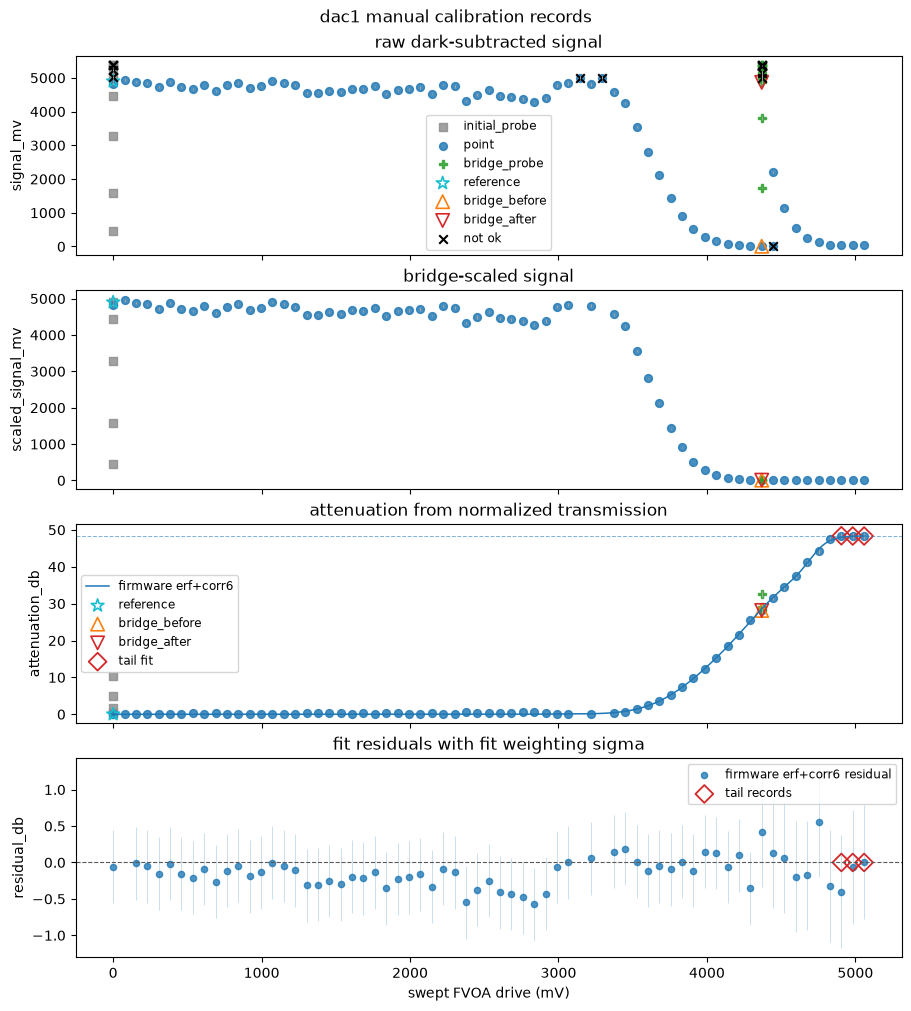

In [13]:

plot_manual_records(dac1_run, [ dac1_fit_corr]);#, dac1_fit, dac1_fit_field_corr]);
# dac1_fit_sp = fit_records(dac1_run, method="scipy", model="erf", correction=False)
# dac1_fit_sp_corr = fit_records(dac1_run, method="scipy", model="erf", correction=True)
# dac1_fit_sp_field_corr = fit_records(dac1_run, method="scipy", model="field", correction=True)
# plot_manual_records(dac1_run, [dac1_fit_sp_corr]);#,dac1_fit_sp, dac1_fit_sp_field_corr]);
# dac1_fit_sp, dac1_fit_sp_corr, dac1_fit_sp_field_corr


In [16]:
dac2_run = acquire_physical("dac2", step_mv=MANUAL_SWEEP_STEP_MV)
dac2_fit = fit_records(dac2_run, method=MANUAL_FIT_METHOD, model=MANUAL_FIT_MODEL)
dac2_fit


PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=1053.690 threshold_mv=10.000 uptime_s=0


initial_probe  dac2=    0.00 other= 1650.00 signal= 5377.073+/- 0.025 snr=215082.92 classification=saturated  segment=0
initial_probe  dac2=    0.00 other= 2475.00 signal= 5377.005+/- 0.023 snr=233782.83 classification=saturated  segment=0
initial_probe  dac2=    0.00 other= 2887.50 signal= 5376.915+/- 0.029 snr=185410.86 classification=saturated  segment=0
initial_probe  dac2=    0.00 other= 3093.75 signal= 1243.882+/- 9.436 snr=  131.82 classification=ok         segment=0
initial_probe  dac2=    0.00 other= 2990.62 signal= 5299.807+/-24.775 snr=  213.92 classification=saturated  segment=0
initial_probe  dac2=    0.00 other= 3042.19 signal= 2525.032+/-20.076 snr=  125.77 classification=ok         segment=0


PCB warning photodiode_adc_error: photodiode ADC sample discarded context=channel=hk rc=-5 uptime_s=0
PCB warning photodiode_adc_error: photodiode ADC sample discarded context=channel=yj rc=-5 uptime_s=0


initial_probe  dac2=    0.00 other= 3016.41 signal= 3553.927+/-36.700 snr=   96.84 classification=ok         segment=0
initial_probe  dac2=    0.00 other= 3003.52 signal= 4422.217+/-47.257 snr=   93.58 classification=ok         segment=0
initial_probe  dac2=    0.00 other= 2997.07 signal= 4828.950+/-50.926 snr=   94.82 classification=ok         segment=0
initial_probe  dac2=    0.00 other= 2993.85 signal= 5008.762+/-54.007 snr=   92.74 classification=saturated  segment=0
point          dac2=    0.00 other= 2997.07 signal= 4860.667+/-48.193 snr=  100.86 classification=ok         segment=0
point          dac2=   50.00 other= 2997.07 signal= 4741.425+/-59.191 snr=   80.10 classification=ok         segment=0
point          dac2=  100.00 other= 2997.07 signal= 4753.342+/-55.694 snr=   85.35 classification=ok         segment=0
point          dac2=  150.00 other= 2997.07 signal= 4769.557+/-57.839 snr=   82.46 classification=ok         segment=0
point          dac2=  200.00 other= 2997.07 sign

PCB warning photodiode_adc_error: photodiode ADC sample discarded context=channel=hk rc=-5 uptime_s=0
PCB warning photodiode_adc_error: photodiode ADC sample discarded context=channel=yj rc=-5 uptime_s=0


...

PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=55.959 threshold_mv=10.000 uptime_s=0


point          dac2= 2750.00 other= 2514.14 signal=  345.637+/- 3.211 snr=  107.64 classification=ok         segment=1
point          dac2= 2800.00 other= 2514.14 signal=  172.815+/- 1.939 snr=   89.13 classification=ok         segment=1
point          dac2= 2850.00 other= 2514.14 signal=  102.323+/- 1.605 snr=   63.75 classification=ok         segment=1


PCB warning photodiode_adc_error: photodiode ADC sample discarded context=channel=yj rc=-5 uptime_s=0


point          dac2= 2900.00 other= 2514.14 signal=   67.522+/- 0.343 snr=  196.86 classification=ok         segment=1
point          dac2= 2950.00 other= 2514.14 signal=   35.580+/- 0.656 snr=   54.24 classification=ok         segment=1
point          dac2= 3000.00 other= 2514.14 signal=   18.615+/- 0.601 snr=   30.97 classification=ok         segment=1
point          dac2= 3050.00 other= 2514.14 signal=   12.037+/- 0.317 snr=   37.97 classification=ok         segment=1
point          dac2= 3100.00 other= 2514.14 signal=    5.933+/- 0.291 snr=   20.39 classification=ok         segment=1
point          dac2= 3150.00 other= 2514.14 signal=    3.592+/- 0.308 snr=   11.66 classification=ok         segment=1
point          dac2= 3200.00 other= 2514.14 signal=    3.158+/- 0.230 snr=   13.73 classification=ok         segment=1
point          dac2= 3250.00 other= 2514.14 signal=    3.210+/- 0.268 snr=   11.98 classification=ok         segment=1
point          dac2= 3300.00 other= 2514.14 sign

{'method': 'firmware',
 'model': 'erf',
 'correction': True,
 'physical': 'dac2',
 'accepted': True,
 'points': 56,
 'fvoa_50pct_mv': 3011.411865519434,
 'slope_inv_fvoa_mv': 0.00215945639636062,
 'max_atten_db': 63.55631985291998,
 'max_atten_sigma_db': 0.33057011717649104,
 'correction_coeff': (-22.112706513178313,
  -25.917749124513154,
  -37.28883058915935,
  -17.13554543160473),
 'floor_tx': 4.409283413866132e-07,
 'gain': 1.533,
 'rms_db': 0.5875289988656486,
 'max_abs_db': 2.636197964247174,
 'min_tx': 3.787746781100626e-07,
 'max_tx': 0.996093767796312,
 'tail_record_indices': (85, 86, 87)}

{'method': 'firmware',
 'model': 'erf',
 'correction': True,
 'correction_status': 'accepted',
 'correction_order': 8,
 'correction_ridge': 1e-06,
 'physical': 'dac2',
 'accepted': True,
 'points': 56,
 'fvoa_50pct_mv': 3011.411865519434,
 'slope_inv_fvoa_mv': 0.00215945639636062,
 'max_atten_db': 63.55631985291998,
 'max_atten_sigma_db': 0.33057011717649104,
 'correction_coeff': (-39.81422992837285,
  -51.40211718875126,
  -69.92873164351332,
  -39.02305387993441,
  -23.86876968663611,
  -14.375867936491169,
  -8.915693177722636,
  -6.280103126780205),
 'floor_tx': 4.409283413866132e-07,
 'gain': 1.533,
 'rms_db': 0.35611518023160743,
 'max_abs_db': 1.1025554064129395,
 'min_tx': 3.787746781100626e-07,
 'max_tx': 0.996093767796312,
 'tail_record_indices': (85, 86, 87)}

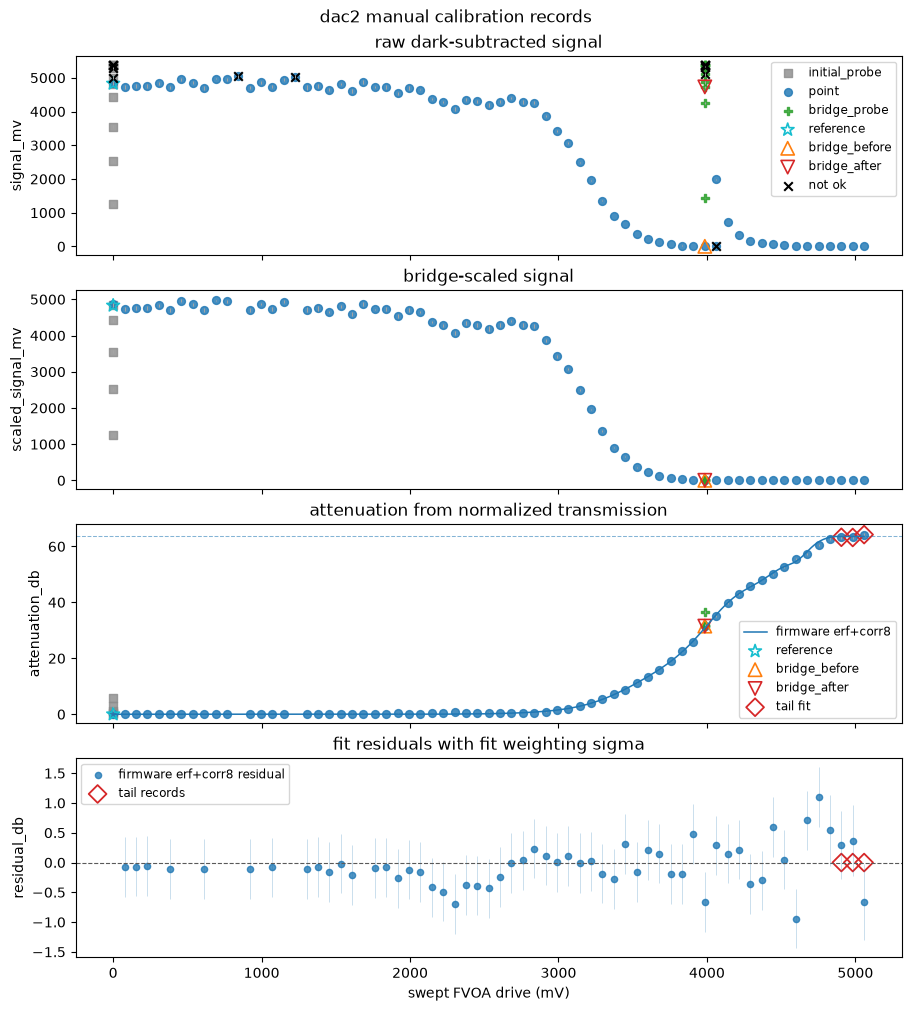

In [23]:
dac2_run = CalRun.load("dac2_run.pickle")
dac2_fit = fit_records(dac2_run, method=MANUAL_FIT_METHOD, model="erf")
# dac2_fit_field = fit_records(dac2_run, method=MANUAL_FIT_METHOD, model="field")
plot_manual_records(dac2_run, [dac2_fit]);#, dac2_fit_field]);
dac2_fit#, dac2_fit_field


In [19]:
# dac2_run.save("dac2_run.pickle")

In [23]:
manual_records = [asdict(record) for record in dac1_run.records + dac2_run.records]
manual_coeff = {
    "dac1": {k: dac1_fit[k] for k in ("fvoa_50pct_mv", "slope_inv_fvoa_mv", "gain")},
    "dac2": {k: dac2_fit[k] for k in ("fvoa_50pct_mv", "slope_inv_fvoa_mv", "gain")},
}
manual_dataset = runs_to_dataset(dac1_run, dac2_run)
manual_coeff


NameError: name 'asdict' is not defined

PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=10.294 threshold_mv=10.000 uptime_s=0


In [ ]:
manual_dataset.bridge_table()


In [ ]:
manual_dataset.plot_surface(manual_coeff["dac1"], manual_coeff["dac2"], overlay_records=True)


In [ ]:
# Review plots before applying. Keep persist=False until repeated and accepted.
# pcb.set_atten_coeff(LASER, manual_coeff["dac1"], manual_coeff["dac2"], persist=False)

